## <center>Problem Sheet #3</center>

<img src="betterstudents.gif" width="700">

<br>
##  Poisson equation in 2D
<br>

#### Homogeneous Dirichlet boundary condition and the five-point stencil
<br>

<b>Problem 1.</b> Let us consider the Poisson equation on the domain $\Omega=(0,1)\times(0,1)$ with homogeneous Dirichlet boundary condition, i.e.

\begin{cases}
-\Delta u= f\quad \textrm{in}\ \Omega\\
u\big|_{\Gamma}=0, &
\end{cases}
where $f(x,y)=\sin(\pi x)\sin(\pi y)$. Let us apply the standard difference star (five-point stencil) with the same step size in both direction.

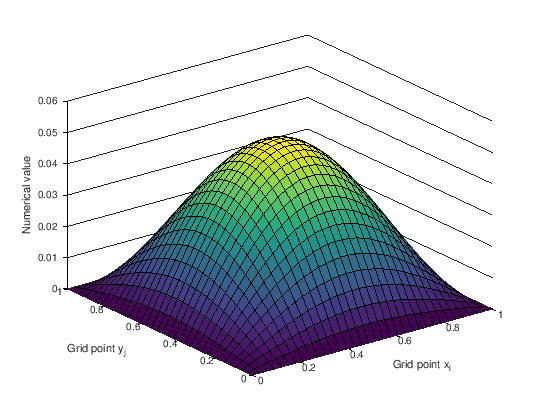

In [2]:
N=32; % Number of (Inner) grid points
h=1/(N+1);
% Creating the block matrix
e=ones(N,1);
B=spdiags([-e 4*e -e], [-1 0 1], N,N);
C=spdiags([-e -e],[-1 1],N,N);
I=speye(N);
A_h=1/(h^2)*(kron(I,B)+kron(C,I));
% Grid points; evaluation of the right hand side function f

%x=linspace(0+h,1-h,N); y=x;  % Another option x=h*[1:N], y=x;
% [xi,yj]=meshgrid(x,y);
[xi,yj]=meshgrid(h:h:1-h,h:h:1-h);
fsquare=sin(pi*xi).*sin(pi*yj);
f=reshape(fsquare',N^2,1);
% Numerical solution 
yv=A_h\f; %N^2 long vector
ysquare=reshape(yv,N,N);
ysquare=ysquare';% NxN matrix
y=zeros(N+2);
y(2:N+1,2:N+1)=ysquare;
% Plot
[X,Y]=meshgrid(0:h:1,0:h:1);
surf(X,Y,y)
xlabel('Grid point x_i')
ylabel('Grid point y_j')
zlabel('Numerical value')


<b>Problem 2.</b> Modify Problem 1. appropriately if we use left-right and down-up numbering!

X =

   0.00000   0.25000   0.50000   0.75000   1.00000
   0.00000   0.25000   0.50000   0.75000   1.00000
   0.00000   0.25000   0.50000   0.75000   1.00000
   0.00000   0.25000   0.50000   0.75000   1.00000
   0.00000   0.25000   0.50000   0.75000   1.00000

Y =

   1.00000   1.00000   1.00000   1.00000   1.00000
   0.75000   0.75000   0.75000   0.75000   0.75000
   0.50000   0.50000   0.50000   0.50000   0.50000
   0.25000   0.25000   0.25000   0.25000   0.25000
   0.00000   0.00000   0.00000   0.00000   0.00000



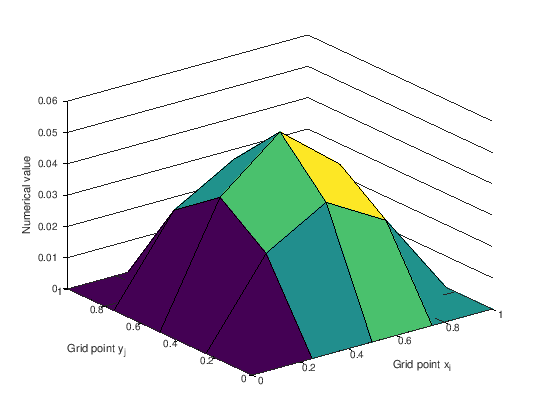

<b>Problem 3.</b> Let us modify Problem 1. such that $\Omega=(0,4)\times(0,1)$ and $h_1\neq h_2$.

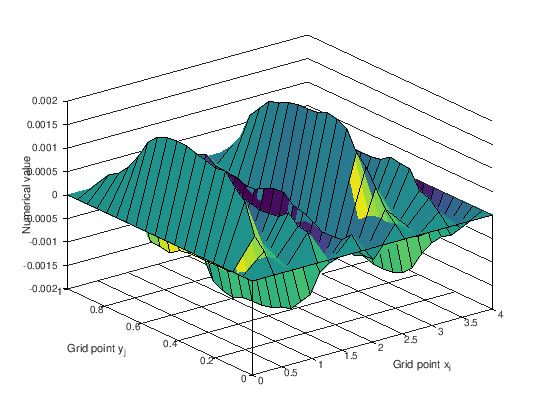

<b>Problem 4.</b> Modify Problem 3. appropriately if we use left-right and down-up numbering!

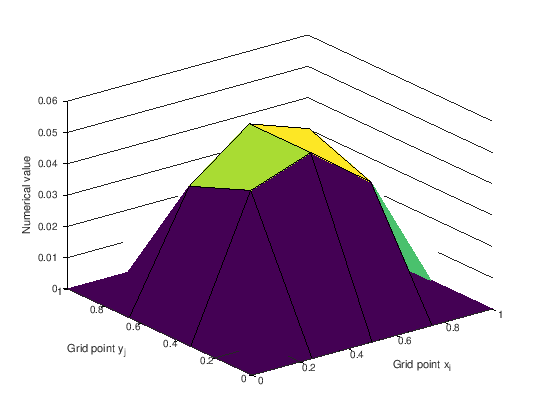

<b>Problem 5.</b> Let us consider the Poisson equation on domain $\Omega=(0,1)\times(0,1)$, i.e.

\begin{cases}
-\Delta u= f\quad \Omega\textrm{-n}\\
u\big|_{\Gamma}=g, &
\end{cases}
where $f(x,y)=\sin(\pi x)(2+(1-y^2)\pi^2)$ and on the boundary we have the condition $u(x,0)=sin(\pi x)$. Then the true solution is $u(x,y)=(1-y^2)\sin(\pi x)$. Let us apply the five-point stencil with the same step size in both direction. What can we experience by increasing the number of the subintervals? What is the order of the method?

norm_maxmax =    3.3439e-04


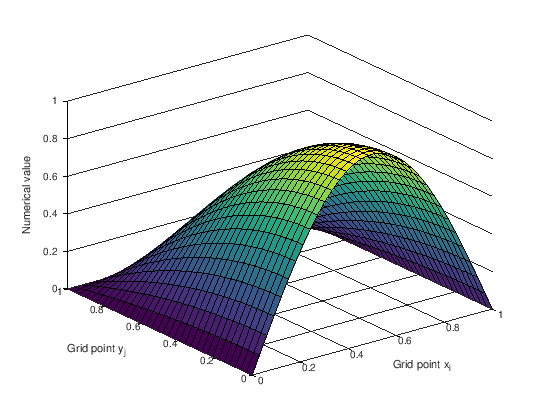

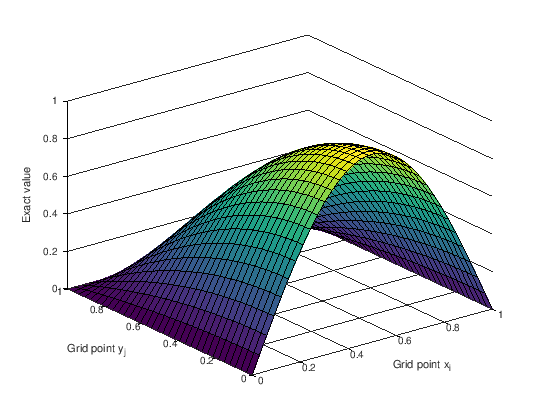

In [17]:
N=32; % (Inner) grid points
h=1/(N+1);
% Creating the block matrix
e=ones(N,1);
B=spdiags([-e 4*e -e], [-1 0 1], N,N);
C=spdiags([-e -e],[-1 1],N,N);
I=speye(N);
A_h=1/(h^2)*(kron(I,B)+kron(C,I));
% Grid points; evaluation of the right hand side function f
%x=linspace(0+h,1-h,N); y=x;  % Másik opció x=h*[1:N], y=x;
% [xi,yj]=meshgrid(x,y);
[xi,yj]=meshgrid(h:h:1-h,h:h:1-h);
fsquare=sin(pi*xi).*(2+(1-yj.^2)*pi^2);
f=reshape(fsquare',N^2,1);
g=sin(pi*h*[1:N]);
f(1:1:N)=f(1:1:N)+g'/h^2;
% Numerical solution
%b=reshape(f,N^2,1); % because of the source
%b(1:N:N^2)=b(1:N:N^2)+g'/h^2;
yv=A_h\f; %N^2 long vector
ysquare=reshape(yv,N,N);
ysquare=ysquare';% NxN matrix
y=zeros(N+2);
y(2:N+1,2:N+1)=ysquare;
y(1,1:N+2)=sin(pi*h*[0:N+1]);% Now we put back the boundary
% Plot
[X,Y]=meshgrid(0:h:1,0:h:1);
surf(X,Y,y)
xlabel('Grid point x_i')
ylabel('Grid point y_j')
zlabel('Numerical value')
figure
[xexact,yexact]=meshgrid(0:h:1,0:h:1);
exact=sin(pi*xexact).*((1-yexact.^2));
surf(xexact,yexact,exact)
xlabel('Grid point x_i')
ylabel('Grid point y_j')
zlabel('Exact value')
norm_maxmax=max(max(abs(y-exact)))


<b>Problem 6.</b> Modify Problem 5. appropriately if we use left-right and down-up numbering!

norm_maxmax =    3.3439e-04


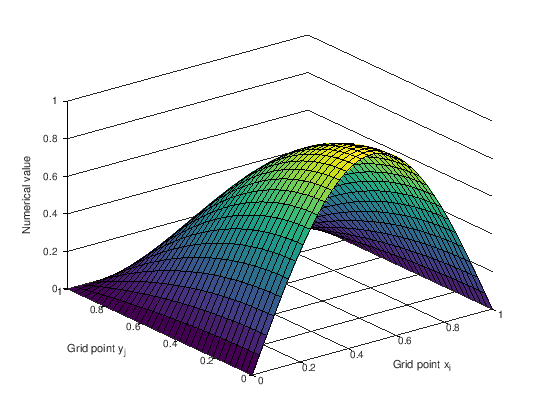

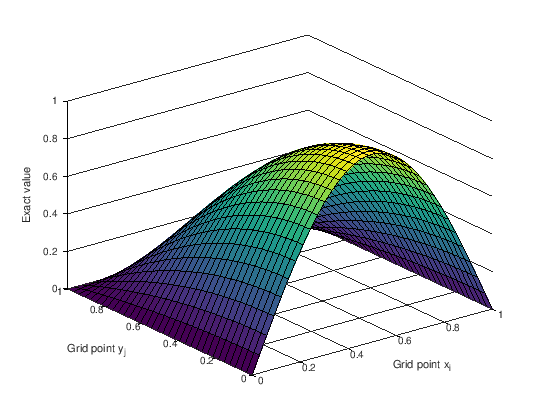